In [6]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
import sisl

In [7]:
# sns.set_theme(style="whitegrid", context="paper")

# 2. Fine-tune specific font sizes and behaviors

title_size = 20
plt.rcParams.update({
    "font.family": "serif",        # Use serif for a formal/academic look
    "font.size": title_size-6,               # Base font size
    "axes.titlesize": title_size-2,          # Subplot titles (your .set(title=...) calls)
    "axes.labelsize": title_size-3,          # X and Y axis labels
    "xtick.labelsize": title_size-4,         # Size of numbers on X-axis
    "ytick.labelsize": title_size-4,         # Size of numbers on Y-axis
    "legend.fontsize": title_size-3,         # Legend text
    'legend.title_fontsize': title_size-2,
    "figure.titlesize": title_size,        # Overall figure title
    "axes.labelpad": 4,           # Distance between label and axis
    "mathtext.fontset": "cm",      # Computer Modern (LaTeX look for math)
    "savefig.dpi": 300             # High-res exports
})

In [27]:
BOND = 1.42
OUTER_R = BOND
B = BOND*np.sqrt(3)/2
INNER_R = B

N0 = 3
N1 = 10
KIND = 'armchair'
R = (0.1, BOND+1e-2)
T = (0.0, -2.7)

BAND_POINTS = np.array([
    [0.0, 0.0, 0.0], # Gamma
    [0.5, 0.0, 0.0], # K_x
])
BAND_NAMES = np.array([
    r"$\Gamma$", # [0, 0, 0]
    r"$\mathrm{K}_x$", # [1/2, 0, 0]
])
NUM_K = 200
NUM_E = 1_000


PATH = (BAND_POINTS, BAND_NAMES, NUM_K)


In [33]:
# graphene = sisl.geom.graphene_nanoribbon(width=N1*2, bond=BOND, kind=KIND)
# graphene = graphene.tile(N0, 0)

# HAM = sisl.Hamiltonian(graphene)
# HAM.construct([R, T])
# xyz = HAM.xyz
# x, y, z = xyz.T

# ymin = y.min()
# ymax = y.max()
# dist_tol = INNER_R
# top_idx, = np.where(np.abs(y - ymax) < dist_tol)
# bottom_idx, = np.where(np.abs(y - ymin) < dist_tol)
# edge_idx = np.concat([top_idx, bottom_idx])
# bulk_idx = np.delete(np.arange(HAM.na), edge_idx)

In [34]:
# bands = sisl.BandStructure(HAM, points=BAND_POINTS, divisions=NUM_K, names=BAND_NAMES)
# lk, kt, kl = bands.lineark(ticks=True)
# kpts = bands.k
# eigs = bands.apply.array.eigh()
# energies = np.linspace(eigs.min(), eigs.max(), num=NUM_E)
# es = HAM.eigenstate(kpts)
# pdos = es.PDOS(energies).squeeze()
# print(pdos.shape)

In [35]:
# Hks = np.array([HAM.Hk(k=kpts[i], format='array') for i in range(NUM_K)])
# eigvals, eigvecs = np.linalg.eigh(Hks)

# props = np.abs(eigvecs)**2
#                         #  ik  atomidx  state
# # each of the NUM_K elements (matrices) of eigvecs has shape(ham), with column i being vector for eigval[i]. 
# edge_weights = np.sum(props[:, edge_idx, :], axis=1)
# bulk_weights = np.sum(props[:, bulk_idx, :], axis=1)


In [36]:
# scale = 0.1
# ylim = 2.0

# E = 1
# vals, = np.where(np.isclose(energies, E, atol=1e-2))
# Eidx = vals[0] 

# norm = lambda M: (M - M.min()) / (M.max() - M.min()) * 2e2
# fig, axes = plt.subplots(1,2, figsize=(12, 6))

# axes[0].scatter(x[edge_idx], y[edge_idx], c='red', s=norm(pdos[edge_idx, Eidx]))
# axes[0].scatter(x[bulk_idx], y[bulk_idx], c='grey', s=norm(pdos[bulk_idx, Eidx]))
# axes[0].scatter(x, y, c='k', s=200, marker='o', alpha=0.05, edgecolor='b')

# # axes[1].plot(lk, eigvals, color='k', lw=1)
# for band in range(HAM.na):
#     upper = eigvals[:, band] + (edge_weights[:, band]*scale)
#     lower = eigvals[:, band] - (edge_weights[:, band]*scale)
#     axes[1].fill_between(lk, lower, upper, 
#                          color='r', 
#                          alpha=0.4,
#                          edgecolor='r'
#                          )
#     upper = eigvals[:, band] + (bulk_weights[:, band]*scale)
#     lower = eigvals[:, band] - (bulk_weights[:, band]*scale)
#     axes[1].fill_between(lk, lower, upper, 
#                          color='grey', 
#                          alpha=0.4,
#                          edgecolor='grey'
#                          )
    
# axes[1].set_ylim(-ylim, ylim)
# axes[1].axhline(energies[Eidx], color='k', linestyle='--', lw=1)
# axes[1].set_xlim(lk[0], lk[-1])
# axes[1].set_xticks(kt, kl)
# axes[0].axis('square')
# fig.tight_layout()
# fig.legend(['Edge', 'Bulk','Place-\nholder', 'Edge', 'Bulk'], bbox_to_anchor=(1.12, 0.65))

In [45]:
def norm(arr):
    scale = 1e2
    norm_arr = (arr - arr.min()) / (arr.max() - arr.min())
    return scale * norm_arr

def compute_pdos(band, energies):
    ham = band.parent
    es = ham.eigenstate()
    pdos = es.PDOS(energies).squeeze()
    return pdos
    
    

def show_fatbands(ham, path, dist_tol=1e-2, E=0, *, ph=False, Erange=2, nE=1_000):
    from matplotlib.legend_handler import HandlerTuple
    scale = 0.1
    if (Erange < 0.1) or (Erange is None):
        Erange = 2
    Erange=(-Erange, Erange)
    xyz = ham.xyz.round(4)
    x, y, z = xyz.T

    ymin = y.min()
    ymax = y.max()
    top_idx, = np.where(np.abs(y - ymax) <= dist_tol)
    bottom_idx, = np.where(np.abs(y - ymin) <= dist_tol)
    edge_idx = np.concat([top_idx, bottom_idx])
    bulk_idx = np.delete(np.arange(ham.na), edge_idx)
    
    points, names, nk = path
    
    bands = sisl.BandStructure(ham, points=points, divisions=nk, names=names)
    lk, kt, kl = bands.lineark(ticks=True)
    kpts = bands.k
    energies = np.linspace(*Erange, num=nE)
    
    exponent = np.log10(nE) -1
    Eidx, = np.where(
        np.isclose(E, energies, atol=10**(-exponent), rtol=10**(-exponent))
        )
    Eidx = Eidx[0]
    
    pdos = compute_pdos(bands, energies)
    norm_pdos = norm(pdos[:, Eidx])
    
    Hks = np.array([ham.Hk(k=kpts[i], format='array') for i in range(nk)])
    eigs, states = np.linalg.eigh(Hks)
    props = np.abs(states)**2
    
    edge_w = np.sum(props[:, edge_idx, :], axis=1)
    bulk_w = np.sum(props[:, bulk_idx, :], axis=1)
    
    fig, ax = plt.subplots(1,2,figsize=(10,6), constrained_layout=True)
    for atom in range(ham.na):
        upper = eigs[:, atom] + (edge_w[:, atom]*scale)
        lower = eigs[:, atom] - (edge_w[:, atom]*scale)
        edgeband = ax[1].fill_between(lk, lower, upper, alpha=0.4, edgecolor='r', color='r')
        
        upper = eigs[:, atom] + (bulk_w[:, atom]*scale)
        lower = eigs[:, atom] - (bulk_w[:, atom]*scale)
        bulkband = ax[1].fill_between(lk, lower, upper, alpha=0.4, edgecolor='grey', color='grey')
        
        if ph:
            ph = ax[0].scatter(x[atom], y[atom], color='grey', s=100, alpha=0.1, edgecolor='k')
        
        # if atom in edge_idx:
        #     edgedot = ax[0].scatter(x[atom], y[atom], color='r', s=norm_pdos[atom])
        #     ax[0].annotate(text=atom, xy=[x[atom], y[atom]])
        # if atom in bulk_idx:
        #     bulkdot = ax[0].scatter(x[atom], y[atom], color='grey', s=norm_pdos[atom])
    
    edgedot = ax[0].scatter(x[edge_idx], y[edge_idx], color='r', s=norm_pdos[edge_idx])
    bulkdot = ax[0].scatter(x[bulk_idx], y[bulk_idx], color='grey', s=norm_pdos[bulk_idx])
    
    # ax[0].axis('scaled')
    ax[0].set_xlabel('x [Å]')
    ax[0].set_ylabel('y [Å]')
    ax[0].set_aspect('equal', adjustable='box')
    ax[0].set_title(fr"$E = {E}$ eV")
    
    # ax[1].set_box_aspect(1.0)
    ax[1].set_xticks(kt, kl)
    ax[1].set_xlabel(r'$\mathbf{k}$ [1/Å]')
    ax[1].set_ylabel(r'$E - \epsilon_F$ [eV]')
    ax[1].set_xlim(lk[0], lk[-1])
    ax[1].set_ylim(*Erange)
    
    # fig.legend([edgeband, bulkband, ph, edgedot, bulkdot], ['Edge', 'Bulk', 'Place-\nholder', 'Edge', 'Bulk'], bbox_to_anchor=(1.2, 0.65))
    handles =   [
        (edgeband, edgedot,),
        (bulkband, bulkdot,),
            ]
    labels = [
        'Edge', 
        'Bulk',
            ]
    if ph:
        handles += [ph]
        labels += ['Place-\nholder']
        
    ax[1].legend(
        handles, 
        labels, 
        handler_map={tuple: HandlerTuple(ndivide=None, pad=0.1)},
        loc='center left',
        bbox_to_anchor=(1.05, 0.5), # 1.05 moves it slightly right of the plot
        borderaxespad=0.
    )
    return fig, ax
    

first calc done
first plot done
second calc done


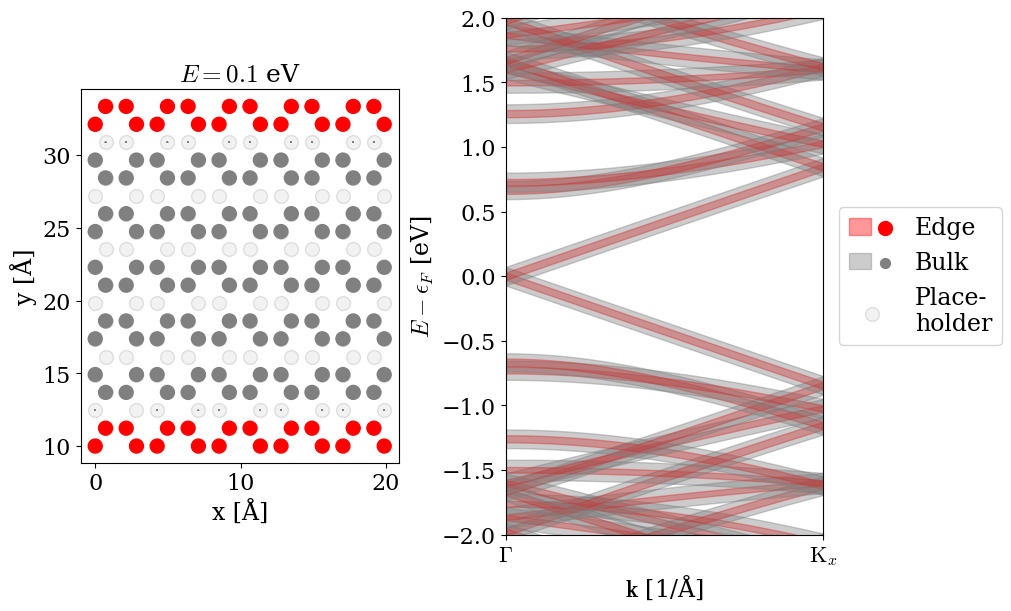

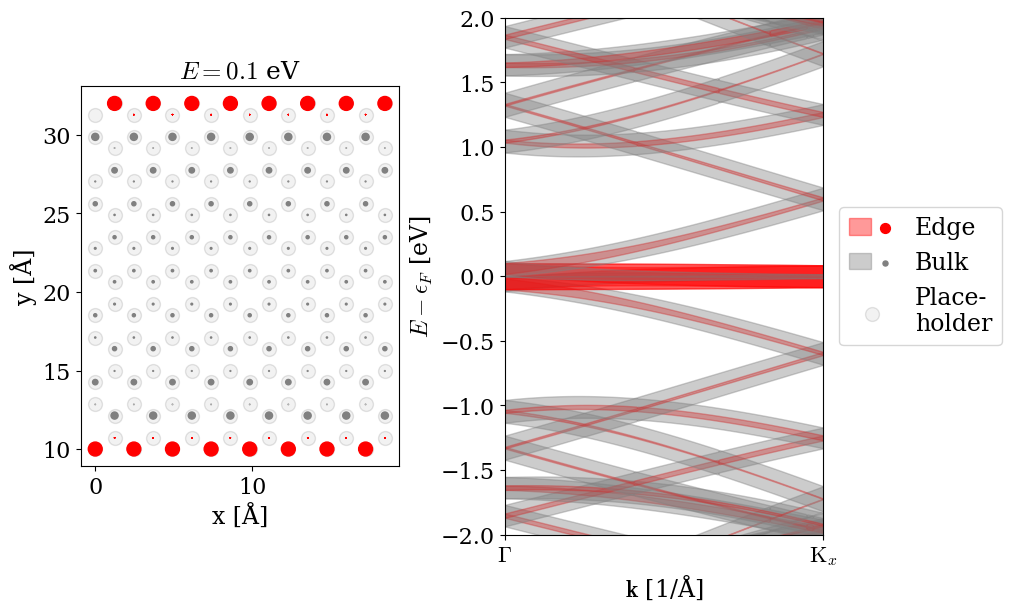

In [ ]:
n0 = 4
n1 = 10
gr = sisl.geom.graphene_nanoribbon(n1*2, BOND, kind='armchair')
gr = gr.tile(n0+1, 0)
ham = sisl.Hamiltonian(gr)
ham.construct([R,T])

show_fatbands(ham, path=PATH, dist_tol=BOND, E=0.1, Erange=2, ph=1);
print("first plot done")

gr = sisl.geom.graphene_nanoribbon(n1+1, BOND, kind='zigzag')
gr = gr.tile(n0*2, 0)
ham = sisl.Hamiltonian(gr)
ham.construct([R, T])

show_fatbands(ham, PATH, dist_tol=B, E=0.1, ph='s');

In [104]:
# gr = sisl.geom.graphene_nanoribbon(N1*2, BOND, kind='zigzag')
# gr = gr.tile(5, 0)
# ham = sisl.Hamiltonian(gr)
# ham.construct([R, T])


# show_fatbands(ham, PATH, dist_tol=B, E=0);